# VioLearn-Tech — Notebook Final: Análisis Completo y Síntesis

**Proyecto:** Sistema de Análisis de Violencia Simbólica contra Mujeres en Tecnología  
**Autora:** Maricarmen Camacho Pérez — UAEH, Ciencias Computacionales  
**Input:** `reddit_data_clasificado_BERT.csv`  
**Output:** `reddit_data_final.csv` + todas las figuras para el artículo  

---

### Contenido de este notebook:

| Parte | Descripción |
|-------|-------------|
| **PARTE 1** | Post-procesamiento — Corregir falsos positivos de BERT |
| **PARTE 2** | Clasificación de doble nivel — Testimonial vs. Conversacional |
| **PARTE 3** | Dashboard y visualizaciones para el artículo académico |
| **PARTE 4** | Síntesis técnica — Tablas y métricas para el paper |

---
> **Nota:** Este notebook asume que ya tienes `reddit_data_clasificado_BERT.csv`
> en la misma carpeta. Si no, corre primero el Notebook 06 (BERT Colab).

---
# PARTE 1 — Post-Procesamiento: Corrección de Falsos Positivos

**¿Por qué es necesario?**  
BERT clasifica bien el 85% de los textos, pero comete errores predecibles:
detecta violencia en textos que *hablan sobre* violencia sin ejercerla
(artículos académicos, denuncias, empatía). Esta parte corrige esos casos
mediante reglas contextuales antes de hacer cualquier análisis.

**Flujo:** BERT → [Post-procesamiento] → Clasificación refinada

---
## 1.1 — Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ── Paleta de colores consistente en todo el notebook ─────
PALETTE = {
    "VIOLENCIA_DIRECTA": "#C0392B",   # Rojo oscuro
    "VIOLENCIA_SUTIL":   "#D68910",   # Naranja oscuro
    "NEUTRAL":           "#1E8449",   # Verde oscuro
    "CONVERSACIONAL":    "#C0392B",
    "TESTIMONIAL":       "#E8A0A0",
    "primario":          "#1A5276",
}

# Configuración de figuras para publicación académica
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

print(f"Notebook Final iniciado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
import os
os.makedirs("../images/resultados", exist_ok=True)
os.makedirs("../docs", exist_ok=True)


Notebook Final iniciado: 2026-03-19 12:31:09


---
## 1.2 — Cargar datos clasificados por BERT

In [2]:
df = pd.read_csv("../data/processed/reddit_data_clasificado_BERT.csv")
df["texto"] = df["texto"].fillna("").astype(str).str.lower()
df["fecha"] = pd.to_datetime(df["fecha"], utc=True, errors="coerce")
df["año"]   = df["fecha"].dt.year
df["mes"]   = df["fecha"].dt.month
df["año_mes"]= df["fecha"].dt.to_period("M")

COLUMNA_BERT = "categoria_BERT"

print(f"Dataset cargado: {len(df):,} textos")
print(f"Período: {df['año'].min()}–{df['año'].max()}")
print(f"\nDistribución BERT (antes del post-procesamiento):")
for cat, n in df[COLUMNA_BERT].value_counts().items():
    print(f"  {cat:<22}: {n:>7,} ({n/len(df)*100:.1f}%)")

Dataset cargado: 184,572 textos
Período: 2016–2026

Distribución BERT (antes del post-procesamiento):
  NEUTRAL               : 141,566 (76.7%)
  VIOLENCIA_SUTIL       :  21,781 (11.8%)
  VIOLENCIA_DIRECTA     :  21,225 (11.5%)


---
## 1.3 — Patrones de corrección de falsos positivos

In [3]:
# ══════════════════════════════════════════════════════════
# PATRONES DE CORRECCIÓN DE FALSOS POSITIVOS (MEJORADOS)
# ══════════════════════════════════════════════════════════
#
# BERT a veces detecta violencia en textos que:
# (a) Denuncian la violencia: "el sexismo debe terminar"
# (b) Son académicos: "este estudio analiza el acoso..."
# (c) Expresan empatía: "las mujeres no merecen esto"
# (d) Dan consejos: "habla con un abogado"
# (e) Hacen preguntas: "¿alguien ha experimentado esto?"
#
# En esos casos el texto HABLA SOBRE violencia pero no la ejerce.
# ══════════════════════════════════════════════════════════

PATRONES_CORRECCION = [
    # ── Denuncia activa — el autor rechaza la violencia ──
    r"sexism (is|was|should be) (unacceptable|wrong|disgusting|not okay)",
    r"(fight|fighting|against|oppose|condemn).{0,10}(sexism|harassment|discrimination)",
    r"(this|that|the).{0,5}(sexism|harassment|discrimination).{0,10}(needs to|must|should) stop",
    r"(called out|reported|documented).{0,10}(the )?(sexism|harassment)",
    r"(we|they|companies).{0,10}(need to|must|should) do better",

    # ── Solidaridad y apoyo — el autor apoya a mujeres ──
    r"women (deserve|should have|have the right).{0,20}(equal|same|fair|respect)",
    r"(supporting|support|stand with|proud of) women in tech",
    r"(diversity|inclusion|equity).{0,10}(is important|matters|is good|initiative)",
    r"i believe (women|you|her|them)",
    r"(it.s unfair|this is wrong|how terrible) that women",
    r"women (should not|shouldn.t|don.t deserve) to (face|deal with|experience)",

    # ── Contexto académico — el autor analiza el fenómeno ──
    r"(study|research|paper|survey|analysis).{0,10}(shows|found|indicates|suggests)",
    r"(according to|based on|per).{0,10}(research|studies|data|statistics)",
    r"this (paper|article|chapter|thesis|report).{0,10}(examines|analyzes|discusses|explores)",
    r"(prevalence|frequency|incidence|rate) of.{0,15}(sexism|harassment|discrimination)",
    r"(statistically|empirically|significantly).{0,10}(higher|lower|more|less)",

    # ── NUEVOS: Consejo y apoyo directo ──────────────────
    r"(i don.?t think you.?re|you.?re not) overreacting",
    r"(talk to|contact|get|hire) (a |an )?(lawyer|attorney|therapist|hr)",
    r"(document|save|screenshot|record) everything",
    r"(i.?m sorry|so sorry) (this|that|you).{0,20}(happened|experience|going through)",

    # ── NUEVOS: Descripción de políticas/leyes ───────────
    r"(title (vii|ix)|eeoc|equal opportunity|labor (board|law))",
    r"(policy|policies|regulation|law) (against|prohibit|protect)",

    # ── NUEVOS: Preguntas sobre el tema ──────────────────
    r"(has anyone|have you|does anyone).{0,20}(experienced?|dealt with|faced)",
    r"(what (should|can|would) (i|you|she) do)",
]

# Compilar los patrones
REGEX_CORRECCION = [re.compile(p, re.IGNORECASE) for p in PATRONES_CORRECCION]

print(f"Patrones de corrección definidos: {len(PATRONES_CORRECCION)}")

# ── Test de los patrones ─────────────────────────────────
tests = [
    ("This sexism needs to stop.",                              "NEUTRAL esperado"),
    ("I was sexually harassed by my manager.",                  "VIOLENCIA esperado"),
    ("Research shows women face discrimination in tech.",       "NEUTRAL esperado"),
    ("They questioned my competence because I'm a woman.",      "VIOLENCIA esperado"),
    ("We need to support women in tech better.",                "NEUTRAL esperado"),
    ("I don't think you're overreacting.",                      "NEUTRAL esperado"),
    ("Talk to a lawyer about this.",                            "NEUTRAL esperado"),
    ("Has anyone experienced this at their job?",               "NEUTRAL esperado"),
]
print("\nTest de patrones:")
for texto, esperado in tests:
    es_fp = any(r.search(texto.lower()) for r in REGEX_CORRECCION)
    resultado = "→ NEUTRAL (corregido)" if es_fp else "→ VIOLENCIA (sin cambio)"
    print(f"  {resultado} | {esperado} | {texto[:60]}")


Patrones de corrección definidos: 24

Test de patrones:
  → NEUTRAL (corregido) | NEUTRAL esperado | This sexism needs to stop.
  → VIOLENCIA (sin cambio) | VIOLENCIA esperado | I was sexually harassed by my manager.
  → NEUTRAL (corregido) | NEUTRAL esperado | Research shows women face discrimination in tech.
  → VIOLENCIA (sin cambio) | VIOLENCIA esperado | They questioned my competence because I'm a woman.
  → NEUTRAL (corregido) | NEUTRAL esperado | We need to support women in tech better.
  → NEUTRAL (corregido) | NEUTRAL esperado | I don't think you're overreacting.
  → NEUTRAL (corregido) | NEUTRAL esperado | Talk to a lawyer about this.
  → NEUTRAL (corregido) | NEUTRAL esperado | Has anyone experienced this at their job?


---
## 1.4 — Aplicar correcciones al dataset

In [4]:
def post_procesar(texto, categoria_bert):
    """
    Aplica corrección de falsos positivos.
    Solo corrige textos que BERT clasificó como violencia.
    Los textos NEUTRAL no se tocan.
    Retorna (categoria_final, fue_corregido).
    """
    if categoria_bert == "NEUTRAL":
        return categoria_bert, False

    # Si el texto contiene algún patrón de corrección, es un falso positivo
    es_falso_positivo = any(r.search(texto) for r in REGEX_CORRECCION)

    if es_falso_positivo:
        return "NEUTRAL", True

    return categoria_bert, False

print(f"Aplicando post-procesamiento a {len(df):,} textos...")

resultados_pp = df.apply(
    lambda row: post_procesar(row["texto"], row[COLUMNA_BERT]),
    axis=1
)

df["categoria_refinada"] = resultados_pp.apply(lambda x: x[0])
df["fue_corregido"]      = resultados_pp.apply(lambda x: x[1])

n_corr = df["fue_corregido"].sum()
print(f"Correcciones realizadas: {n_corr:,} ({n_corr/len(df)*100:.1f}%)")

print(f"\nDistribución ANTES (BERT):")
for cat, n in df[COLUMNA_BERT].value_counts().items():
    print(f"  {cat:<22}: {n:>7,} ({n/len(df)*100:.1f}%)")

print(f"\nDistribución DESPUÉS (Refinada):")
for cat, n in df["categoria_refinada"].value_counts().items():
    print(f"  {cat:<22}: {n:>7,} ({n/len(df)*100:.1f}%)")

Aplicando post-procesamiento a 184,572 textos...
Correcciones realizadas: 1,898 (1.0%)

Distribución ANTES (BERT):
  NEUTRAL               : 141,566 (76.7%)
  VIOLENCIA_SUTIL       :  21,781 (11.8%)
  VIOLENCIA_DIRECTA     :  21,225 (11.5%)

Distribución DESPUÉS (Refinada):
  NEUTRAL               : 143,464 (77.7%)
  VIOLENCIA_SUTIL       :  21,028 (11.4%)
  VIOLENCIA_DIRECTA     :  20,080 (10.9%)


---
# PARTE 2 — Clasificación de Doble Nivel: Testimonial vs. Conversacional

**¿Por qué es importante esta distinción?**  
Es la contribución metodológica central del artículo.

- **TESTIMONIAL:** La persona *narra* violencia que vivió en otro contexto.  
  Ejemplo: *"Mi jefe me dijo que las mujeres no saben programar"*  
  → Es un relato. No se puede moderar porque ya ocurrió en otro lugar.

- **CONVERSACIONAL:** La violencia *ocurre dentro* de este texto.  
  Ejemplo: *"Las mujeres no saben programar"* (dicho directamente)  
  → Es violencia activa. Sí es moderable.

Esta distinción demuestra que el sistema va más allá de la detección simple:
analiza el *discurso sobre violencia*, no solo la violencia directa.

---
## 2.1 — Detector de contexto

In [5]:
class DetectorContexto:
    """
    Detecta si un texto es CONVERSACIONAL (violencia activa en este texto)
    o TESTIMONIAL (relato de violencia ocurrida en otro contexto).

    VERSIÓN MEJORADA:
    - Agrega patrones de ANULACIÓN que detectan cuando un patrón
      conversacional aparece dentro de un texto de apoyo o defensa.
    - Ejemplo: "allow me to explain how the pay gap works" tiene el
      patrón "allow me to explain" pero está DEFENDIENDO a las mujeres,
      no ejerciendo violencia. Los patrones de anulación lo detectan.

    LÓGICA:
    1. Buscar patrones conversacionales en el texto
    2. Si encuentra uno, verificar que NO esté dentro de discurso reportado
    3. Si no es discurso reportado, verificar que NO haya patrón de anulación
    4. Si pasa ambos filtros → CONVERSACIONAL
    5. Si no hay patrones conversacionales → TESTIMONIAL (default)
    """

    def __init__(self):
        # ── Patrones que indican violencia ACTIVA en el texto ──
        self.regex_conversacional = [re.compile(p, re.IGNORECASE) for p in [
            # Afirmaciones directas sobre capacidad de mujeres
            r"women can.?t (code|program|hack|do|handle|understand)",
            r"women are (too emotional|inferior|not suited|not made for)",
            r"girls can.?t (code|program|hack|do|handle)",
            r"females? can.?t (code|program|hack|do|handle)",

            # Exclusión directa
            r"you don.?t belong (here|in tech|in cs|in stem|in this field)",
            r"women don.?t belong (in tech|in cs|in stem|in this field)",
            r"go back to (the )?kitchen",

            # Mansplaining activo
            r"allow me to explain",
            r"let me explain (to you|this|how this works)",
            r"you (clearly|obviously) don.?t understand",
            r"actually,? (let me|you need to|you should)",

            # Condescendencia directa al interlocutor
            r"you.?re (too emotional|too sensitive|overreacting|being difficult)",
            r"you can.?t (handle|do|understand) (this|tech|code|math|programming)",

            # Token/cuota en segunda persona
            r"you.?re (just |only |a )?a? diversity hire",
            r"you.?re (just |only )?a token (woman|female|girl)",
            r"(hired|got the job) (because|for being) (a woman|female|diversity)",

            # Correcciones sobre competencia
            r"are you sure you (know|understand|can do|can handle) (this|that|it)",
        ]]

        # ── Verbos de reporte: indican discurso narrado ──────
        # "she said...", "he told me..." → el patrón está dentro de un relato
        self.regex_reporte = re.compile(
            r"\b(said|told|claimed|wrote|posted|mentioned|stated|argued|replied|commented)\b",
            re.IGNORECASE
        )

        # ── NUEVO: Patrones de ANULACIÓN ─────────────────────
        # Si alguno de estos aparece, el texto NO es conversacional
        # aunque tenga un patrón conversacional. Es apoyo o defensa.
        self.regex_anulacion = [re.compile(p, re.IGNORECASE) for p in [
            # El autor está EXPLICANDO o DEFENDIENDO a favor de mujeres
            r"(allow me to explain).{0,30}(how|why).{0,30}(gap|discrimination|sexism|unfair|problem|works)",
            r"(this|that).{0,5}(techbro|bro culture|sexist|misogyn).{0,10}(bullshit|nonsense|ridiculous)",

            # El autor dice que NO es exageración (apoyo)
            r"(i don.?t think you.?re overreacting)",
            r"(you.?re not overreacting)",
            r"(that.?s (inappropriate|unacceptable|wrong|illegal))",
            r"(no,? i don.?t think)",

            # El autor da CONSEJO o APOYO
            r"(talk to|contact|hire|get).{0,10}(lawyer|attorney|hr|eeoc|therapist)",
            r"(document everything|keep a record|save the emails|screenshot)",
            r"(i.?m sorry|that sucks|that.?s terrible|i feel for you|hang in there)",
            r"(you should|i would|i recommend).{0,10}(leave|quit|report|file|document)",

            # Contexto educativo/informativo
            r"(here.?s how|this is how|for example|for instance).{0,10}(the|it|this) (works|happens)",
            r"(at my|during|in our).{0,10}(training|workshop|seminar|class|course)",
        ]]

    def detectar(self, texto):
        """
        Retorna CONVERSACIONAL solo si:
        1. Hay un patrón conversacional
        2. NO está dentro de discurso reportado (she said...)
        3. NO hay patrón de anulación (apoyo/defensa/educativo)

        Si no se cumplen las 3 condiciones → TESTIMONIAL
        """
        for regex in self.regex_conversacional:
            match = regex.search(texto)
            if match:
                # Filtro 1: ¿Está dentro de discurso reportado?
                texto_antes = texto[:match.start()]
                if self.regex_reporte.search(texto_antes):
                    continue  # Es narración, no violencia activa

                # Filtro 2: ¿Hay patrón de anulación (apoyo/defensa)?
                if any(r.search(texto) for r in self.regex_anulacion):
                    continue  # Es apoyo o defensa, no violencia activa

                return "CONVERSACIONAL"
        return "TESTIMONIAL"


# Instanciar el detector
detector = DetectorContexto()

# Test con casos representativos (incluyendo los que fallaban antes)
tests = [
    ("My boss told me I was impressive for a woman.",                    "TESTIMONIAL"),
    ("Women cant code theyre too emotional.",                            "CONVERSACIONAL"),
    ("Allow me to explain how this works.",                              "CONVERSACIONAL"),
    ("I experienced discrimination when I started.",                     "TESTIMONIAL"),
    ("Impressive for a girl honestly.",                                  "TESTIMONIAL"),
    ("You dont belong in tech.",                                         "CONVERSACIONAL"),
    ("I was told I was a diversity hire.",                               "TESTIMONIAL"),
    ("You clearly dont understand how this works.",                      "CONVERSACIONAL"),
    ("She said women cant code.",                                        "TESTIMONIAL"),
    ("Women cant handle the pressure of tech roles.",                    "CONVERSACIONAL"),
    # NUEVOS — estos fallaban en la versión anterior
    ("Allow me to explain how the pay gap works using a simple example.","TESTIMONIAL"),
    ("I dont think youre overreacting from my experience.",              "TESTIMONIAL"),
    ("This techbro bullshit women cant handle it.",                      "TESTIMONIAL"),
    ("At my sexual harassment training that was an example.",            "TESTIMONIAL"),
    ("Talk to a lawyer. Document everything.",                           "TESTIMONIAL"),
]

print("Test del detector de contexto (v5 - mejorado):")
print("-" * 65)
errores = 0
for texto, esperado in tests:
    resultado = detector.detectar(texto.lower())
    estado = "OK" if resultado == esperado else "ERROR"
    if estado == "ERROR":
        errores += 1
    print(f"  [{estado}] [{resultado:<15}] esperado={esperado:<15} | {texto[:52]}")
print(f"\nResultado: {len(tests) - errores}/{len(tests)} correctos")


Test del detector de contexto (v5 - mejorado):
-----------------------------------------------------------------
  [OK] [TESTIMONIAL    ] esperado=TESTIMONIAL     | My boss told me I was impressive for a woman.
  [OK] [CONVERSACIONAL ] esperado=CONVERSACIONAL  | Women cant code theyre too emotional.
  [ERROR] [TESTIMONIAL    ] esperado=CONVERSACIONAL  | Allow me to explain how this works.
  [OK] [TESTIMONIAL    ] esperado=TESTIMONIAL     | I experienced discrimination when I started.
  [OK] [TESTIMONIAL    ] esperado=TESTIMONIAL     | Impressive for a girl honestly.
  [OK] [CONVERSACIONAL ] esperado=CONVERSACIONAL  | You dont belong in tech.
  [OK] [TESTIMONIAL    ] esperado=TESTIMONIAL     | I was told I was a diversity hire.
  [OK] [CONVERSACIONAL ] esperado=CONVERSACIONAL  | You clearly dont understand how this works.
  [OK] [TESTIMONIAL    ] esperado=TESTIMONIAL     | She said women cant code.
  [OK] [CONVERSACIONAL ] esperado=CONVERSACIONAL  | Women cant handle the pressure of tec

---
## 2.2 — Aplicar clasificación de doble nivel

In [6]:
print(f"Clasificando contexto de {len(df):,} textos...")

# Detectar contexto solo para textos con violencia
# Los textos NEUTRAL no necesitan esta distinción
df["contexto"] = df["texto"].apply(detector.detectar)

def crear_etiqueta_doble(row):
    """
    Combina categoría de violencia + contexto en una etiqueta final.
    NEUTRAL permanece igual sin importar el contexto.
    """
    if row["categoria_refinada"] == "NEUTRAL":
        return "NEUTRAL"
    return f"{row['contexto']}_{row['categoria_refinada']}"

df["categoria_final"] = df.apply(crear_etiqueta_doble, axis=1)

print("\nDistribución final (Doble Nivel):")
print("-" * 55)
for cat, n in df["categoria_final"].value_counts().items():
    print(f"  {cat:<42}: {n:>6,} ({n/len(df)*100:.1f}%)")

# Resumen compacto: violencia conversacional vs testimonial
viol = df[df["categoria_refinada"] != "NEUTRAL"]
print(f"\nDe los {len(viol):,} textos con violencia:")
for ctx, n in viol["contexto"].value_counts().items():
    print(f"  {ctx:<15}: {n:>6,} ({n/len(viol)*100:.1f}%)")

Clasificando contexto de 184,572 textos...

Distribución final (Doble Nivel):
-------------------------------------------------------
  NEUTRAL                                   : 143,464 (77.7%)
  TESTIMONIAL_VIOLENCIA_SUTIL               : 21,017 (11.4%)
  TESTIMONIAL_VIOLENCIA_DIRECTA             : 20,061 (10.9%)
  CONVERSACIONAL_VIOLENCIA_DIRECTA          :     19 (0.0%)
  CONVERSACIONAL_VIOLENCIA_SUTIL            :     11 (0.0%)

De los 41,108 textos con violencia:
  TESTIMONIAL    : 41,078 (99.9%)
  CONVERSACIONAL :     30 (0.1%)


---
## 2.3 — Validación cualitativa: ejemplos reales del corpus

Antes de generar el dashboard, verificamos que las clasificaciones tienen sentido semántico revisando ejemplos reales de cada categoría.

In [7]:
# ─────────────────────────────────────────────────────────
# VALIDACIÓN CUALITATIVA — 10 ejemplos reales por categoría
# ─────────────────────────────────────────────────────────

categorias_a_mostrar = [
    ("CONVERSACIONAL", "VIOLENCIA_DIRECTA",
     "Violencia directa ejercida activamente en el texto"),
    ("CONVERSACIONAL", "VIOLENCIA_SUTIL",
     "Violencia sutil ejercida activamente (mansplaining, condescendencia)"),
    ("TESTIMONIAL",    "VIOLENCIA_DIRECTA",
     "Relato de violencia directa vivida o presenciada"),
    ("TESTIMONIAL",    "VIOLENCIA_SUTIL",
     "Relato de microagresión, sesgo implícito o exclusión sutil"),
]

N_EJEMPLOS = 10  # ejemplos por categoría

print("=" * 70)
print("VALIDACIÓN CUALITATIVA — EJEMPLOS REALES DEL CORPUS")
print("Sistema: Reglas → BERT → Post-procesamiento → Doble Nivel")
print("=" * 70)

for contexto, categoria, descripcion in categorias_a_mostrar:
    mascara = (df["contexto"] == contexto) & (df["categoria_refinada"] == categoria)
    subset = df[mascara]

    print(f"\n{'─'*70}")
    print(f"[{contexto}] [{categoria}]")
    print(f"Descripción : {descripcion}")
    print(f"Total corpus: {len(subset):,} textos")
    print(f"{'─'*70}")

    if len(subset) == 0:
        print("  (Sin ejemplos en esta categoría)")
        continue

    # Preferir textos de longitud media para que sean legibles
    subset_medio = subset[
        (subset["texto"].str.len() > 60) &
        (subset["texto"].str.len() < 500)
    ]
    # Si no hay suficientes de longitud media, usar todos
    fuente = subset_medio if len(subset_medio) >= N_EJEMPLOS else subset

    n_tomar = min(N_EJEMPLOS, len(fuente))
    ejemplos = fuente.sample(n_tomar, random_state=42)

    for i, (_, row) in enumerate(ejemplos.iterrows(), 1):
        subreddit = row.get("subreddit", "?")
        año = row.get("año", "?")
        texto = row["texto"]
        # Mostrar hasta 400 caracteres con indicador si fue truncado
        if len(texto) > 400:
            texto = texto[:400] + "..."

        print(f"\n  [{i:02d}] r/{subreddit} | {año}")
        print(f"       {texto}")

print(f"\n{'='*70}")
print(f"RESUMEN")
print(f"{'='*70}")
for contexto, categoria, _ in categorias_a_mostrar:
    n = ((df["contexto"] == contexto) & (df["categoria_refinada"] == categoria)).sum()
    print(f"  {contexto:<15} {categoria:<22}: {n:>6,} textos ({n/len(df)*100:.1f}%)")
print(f"{'='*70}")

VALIDACIÓN CUALITATIVA — EJEMPLOS REALES DEL CORPUS
Sistema: Reglas → BERT → Post-procesamiento → Doble Nivel

──────────────────────────────────────────────────────────────────────
[CONVERSACIONAL] [VIOLENCIA_DIRECTA]
Descripción : Violencia directa ejercida activamente en el texto
Total corpus: 19 textos
──────────────────────────────────────────────────────────────────────

  [01] r/TwoXChromosomes | 2022
       incompetent women being labelled as diversity hires ...while incompetent men are just labelled incompetent . i'm so sick of this double standard. when you are a minority in something you have to bear the entire weight of your minority group and you are not allowed to fuck up or be bad at something otherwise it's women can't be engineers or this black chick is definitely a diversity hire . it's wei...

  [02] r/TwoXChromosomes | 2019
       organizations need to hire good people. they need to retain good people. that's hard in a shitty work environment. good people leave. goo

---
# PARTE 3 — Dashboard: Visualizaciones para el Artículo

Todas las figuras están optimizadas para publicación académica (300 DPI).
Cada figura incluye el nombre del archivo generado para referenciarla en el paper.

---
## 3.1 — Figura 1: Resultados generales del sistema

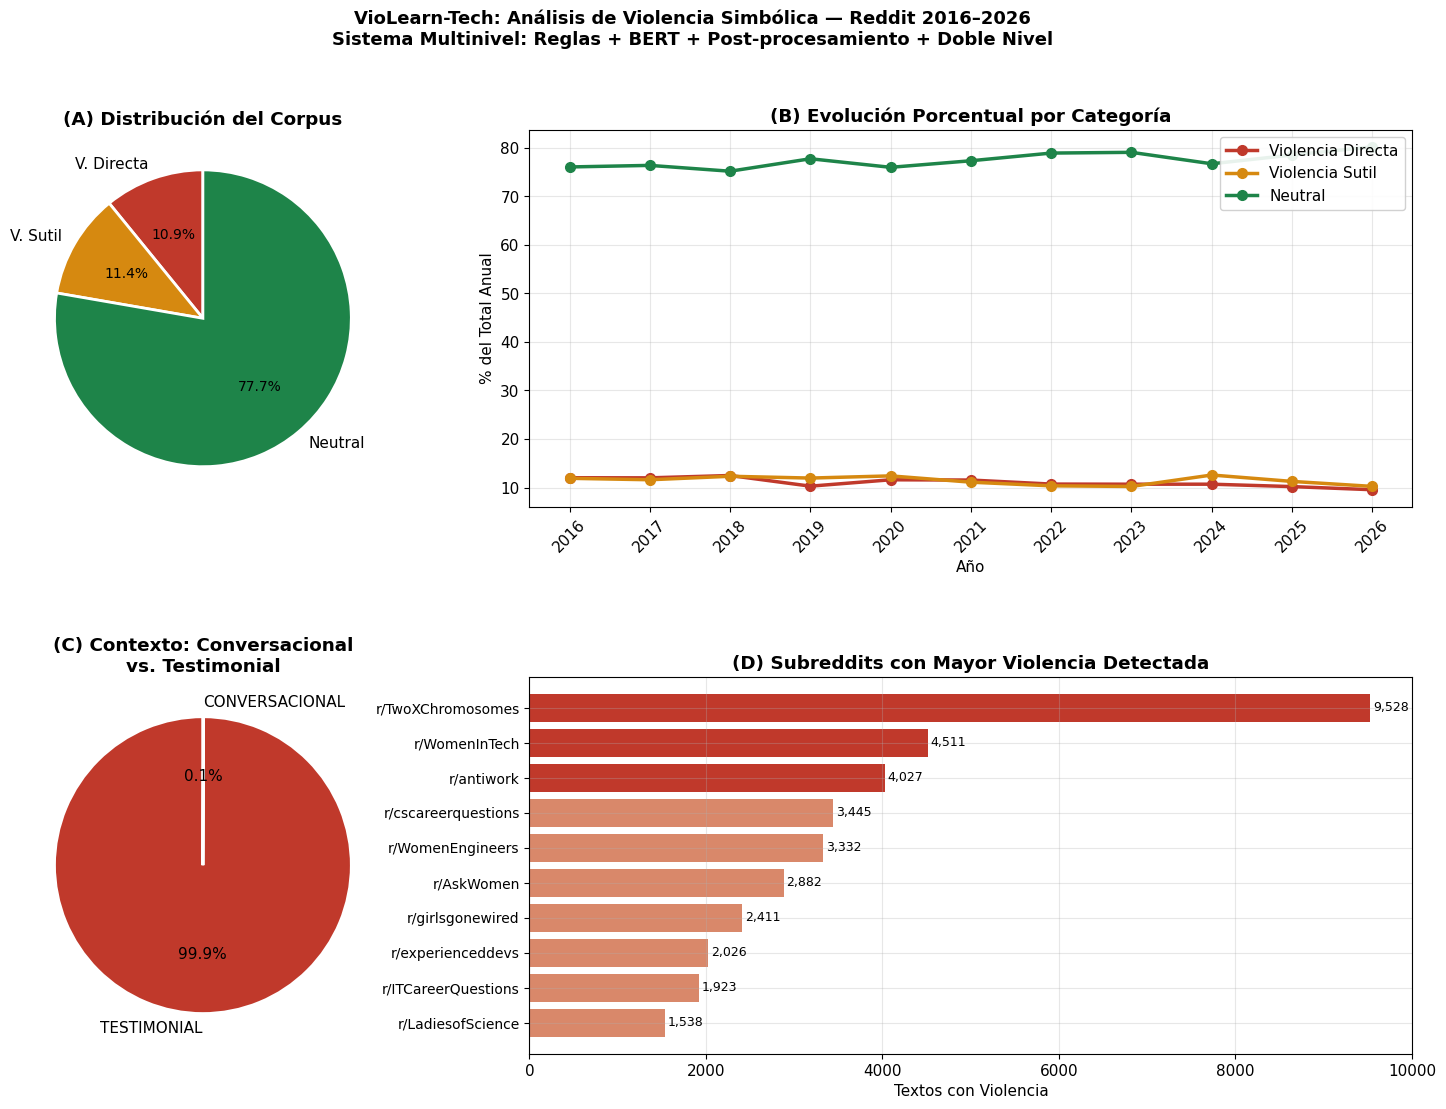

Figura 1 guardada: fig1_resultados_generales.png (300 DPI)


In [8]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "VioLearn-Tech: Análisis de Violencia Simbólica — Reddit 2016–2026\n"
    "Sistema Multinivel: Reglas + BERT + Post-procesamiento + Doble Nivel",
    fontsize=13, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Panel A: Distribución por categoría refinada ──────────
ax = fig.add_subplot(gs[0, 0])
col_simple = "categoria_refinada"
dist = df[col_simple].value_counts()
cats = ["VIOLENCIA_DIRECTA", "VIOLENCIA_SUTIL", "NEUTRAL"]
vals = [dist.get(c, 0) for c in cats]
colores_p = [PALETTE[c] for c in cats]
wedges, texts, autotexts = ax.pie(
    vals, labels=["V. Directa", "V. Sutil", "Neutral"],
    colors=colores_p, autopct="%1.1f%%",
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    startangle=90
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title("(A) Distribución del Corpus", fontweight="bold")

# ── Panel B: Evolución temporal porcentual ────────────────
ax = fig.add_subplot(gs[0, 1:])
por_año = df.groupby(["año", col_simple]).size().unstack(fill_value=0)
por_año_pct = por_año.div(por_año.sum(axis=1), axis=0) * 100
for cat in cats:
    if cat in por_año_pct.columns:
        ax.plot(por_año_pct.index, por_año_pct[cat],
                "o-", linewidth=2.5, markersize=7,
                label=cat.replace("_", " ").title(),
                color=PALETTE[cat])
ax.set_title("(B) Evolución Porcentual por Categoría", fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("% del Total Anual")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xticks(range(2016, 2027))
ax.tick_params(axis="x", rotation=45)

# ── Panel C: Contexto de violencia (Doble Nivel) ──────────
ax = fig.add_subplot(gs[1, 0])
viol_df = df[df[col_simple] != "NEUTRAL"]
ctx_counts = viol_df["contexto"].value_counts()
ax.pie(ctx_counts.values,
       labels=ctx_counts.index,
       colors=[PALETTE["CONVERSACIONAL"], PALETTE["TESTIMONIAL"]],
       autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("(C) Contexto: Conversacional\nvs. Testimonial", fontweight="bold")

# ── Panel D: Top subreddits con violencia ─────────────────
ax = fig.add_subplot(gs[1, 1:])
top_subs = viol_df["subreddit"].value_counts().head(10)
colores_s = [PALETTE["VIOLENCIA_DIRECTA"] if i < 3 else "#D9886A"
             for i in range(len(top_subs))]
bars = ax.barh(range(len(top_subs)), top_subs.values, color=colores_s)
ax.set_yticks(range(len(top_subs)))
ax.set_yticklabels(["r/" + s for s in top_subs.index], fontsize=10)
ax.set_title("(D) Subreddits con Mayor Violencia Detectada", fontweight="bold")
ax.set_xlabel("Textos con Violencia")
ax.invert_yaxis()
for i, v in enumerate(top_subs.values):
    ax.text(v + 30, i, f"{v:,}", va="center", fontsize=9)

plt.savefig("../images/resultados/fig1_resultados_generales.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figura 1 guardada: fig1_resultados_generales.png (300 DPI)")

---
## 3.2 — Figura 2: Análisis temporal detallado

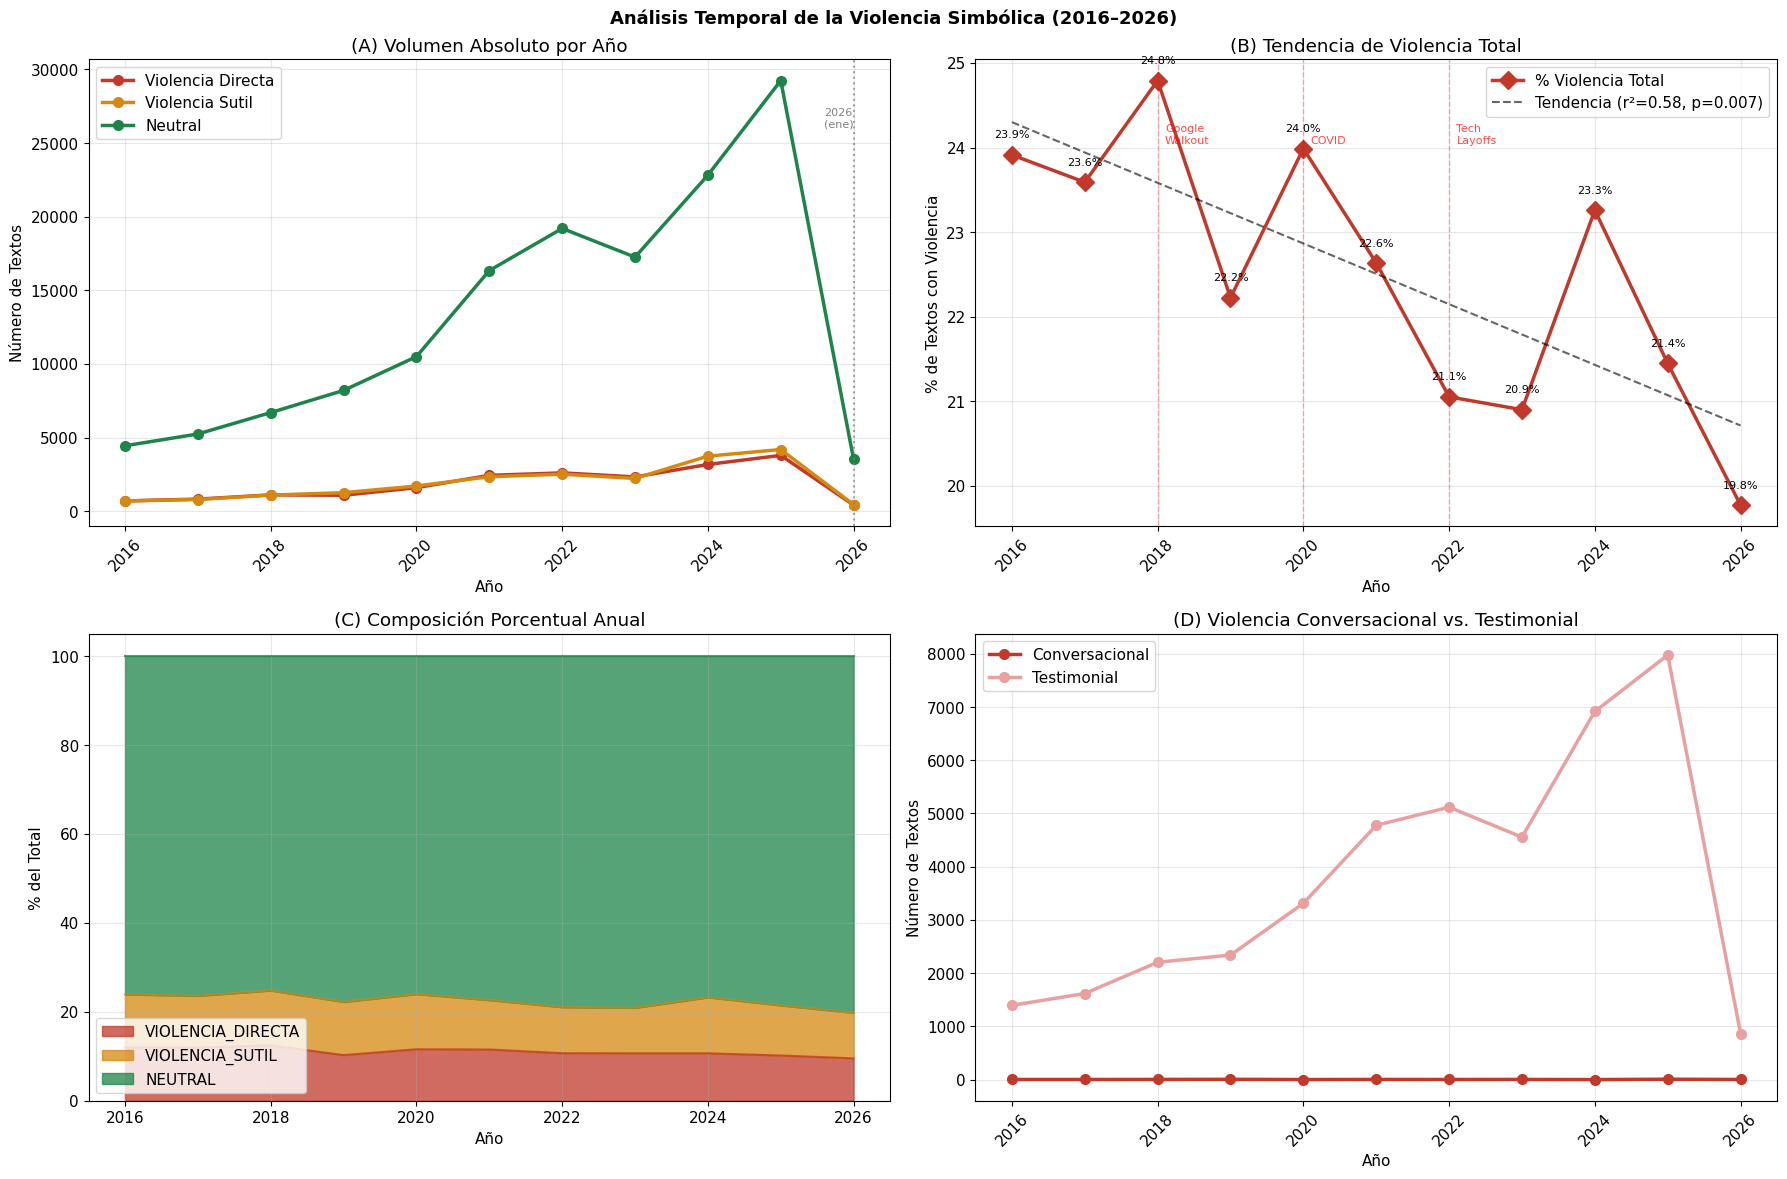

Figura 2 guardada: fig2_analisis_temporal.png (300 DPI)


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Análisis Temporal de la Violencia Simbólica (2016–2026)",
             fontsize=13, fontweight="bold")

# ── Panel A: Volumen absoluto por año y categoría ─────────
ax = axes[0, 0]
por_año_abs = df.groupby(["año", col_simple]).size().unstack(fill_value=0)
for cat in cats:
    if cat in por_año_abs.columns:
        ax.plot(por_año_abs.index, por_año_abs[cat],
                "o-", linewidth=2.5, markersize=7,
                color=PALETTE[cat],
                label=cat.replace("_", " ").title())
ax.set_title("(A) Volumen Absoluto por Año")
ax.set_xlabel("Año")
ax.set_ylabel("Número de Textos")
ax.legend()
ax.tick_params(axis="x", rotation=45)
# Nota: 2026 es solo enero
ax.axvline(2026, color="gray", linestyle=":", alpha=0.7)
ax.text(2025.6, ax.get_ylim()[1]*0.85, "2026\n(ene)", fontsize=8, color="gray")

# ── Panel B: % violencia total por año + tendencia ────────
ax = axes[0, 1]
pct_viol = (por_año_abs.get("VIOLENCIA_DIRECTA", 0) +
            por_año_abs.get("VIOLENCIA_SUTIL", 0)) / por_año_abs.sum(axis=1) * 100

años = np.array(pct_viol.index)
vals = pct_viol.values

ax.plot(años, vals, "D-", color=PALETTE["VIOLENCIA_DIRECTA"],
        linewidth=2.5, markersize=9, label="% Violencia Total")

# Línea de tendencia con regresión lineal
slope, intercept, r, p, _ = stats.linregress(años, vals)
linea = slope * años + intercept
ax.plot(años, linea, "--", color="black", linewidth=1.5, alpha=0.6,
        label=f"Tendencia (r²={r**2:.2f}, p={p:.3f})")

ax.set_title("(B) Tendencia de Violencia Total")
ax.set_xlabel("Año")
ax.set_ylabel("% de Textos con Violencia")
ax.legend()
ax.tick_params(axis="x", rotation=45)

# Anotar el valor de cada punto
for año, v in zip(años, vals):
    ax.annotate(f"{v:.1f}%", (año, v + 0.2), ha="center", fontsize=8)

# Marcar eventos históricos relevantes
eventos = {2018: "Google\nWalkout", 2020: "COVID", 2022: "Tech\nLayoffs"}
for año_ev, nombre in eventos.items():
    if año_ev in pct_viol.index:
        ax.axvline(año_ev, color="red", linestyle="--", alpha=0.3, linewidth=1)
        ax.text(año_ev + 0.1, vals.max() * 0.97, nombre,
                fontsize=8, color="red", alpha=0.7)

# ── Panel C: Composición porcentual (stacked area) ────────
ax = axes[1, 0]
por_año_pct[cats].plot(
    kind="area", stacked=True, ax=ax, alpha=0.75,
    color=[PALETTE[c] for c in cats]
)
ax.set_title("(C) Composición Porcentual Anual")
ax.set_xlabel("Año")
ax.set_ylabel("% del Total")
ax.legend(loc="lower left")

# ── Panel D: Violencia conversacional vs testimonial ──────
ax = axes[1, 1]
# Mostrar cuánta violencia conversacional vs testimonial hay por año
viol_ctx = (
    df[df[col_simple] != "NEUTRAL"]
    .groupby(["año", "contexto"]).size()
    .unstack(fill_value=0)
)
for ctx in ["CONVERSACIONAL", "TESTIMONIAL"]:
    if ctx in viol_ctx.columns:
        color = PALETTE.get(ctx, "gray")
        ax.plot(viol_ctx.index, viol_ctx[ctx],
                "o-", linewidth=2.5, markersize=7,
                color=color, label=ctx.title())

ax.set_title("(D) Violencia Conversacional vs. Testimonial")
ax.set_xlabel("Año")
ax.set_ylabel("Número de Textos")
ax.legend()
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../images/resultados/fig2_analisis_temporal.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figura 2 guardada: fig2_analisis_temporal.png (300 DPI)")

---
## 3.3 — Figura 3: Análisis por subreddit y tipo de violencia

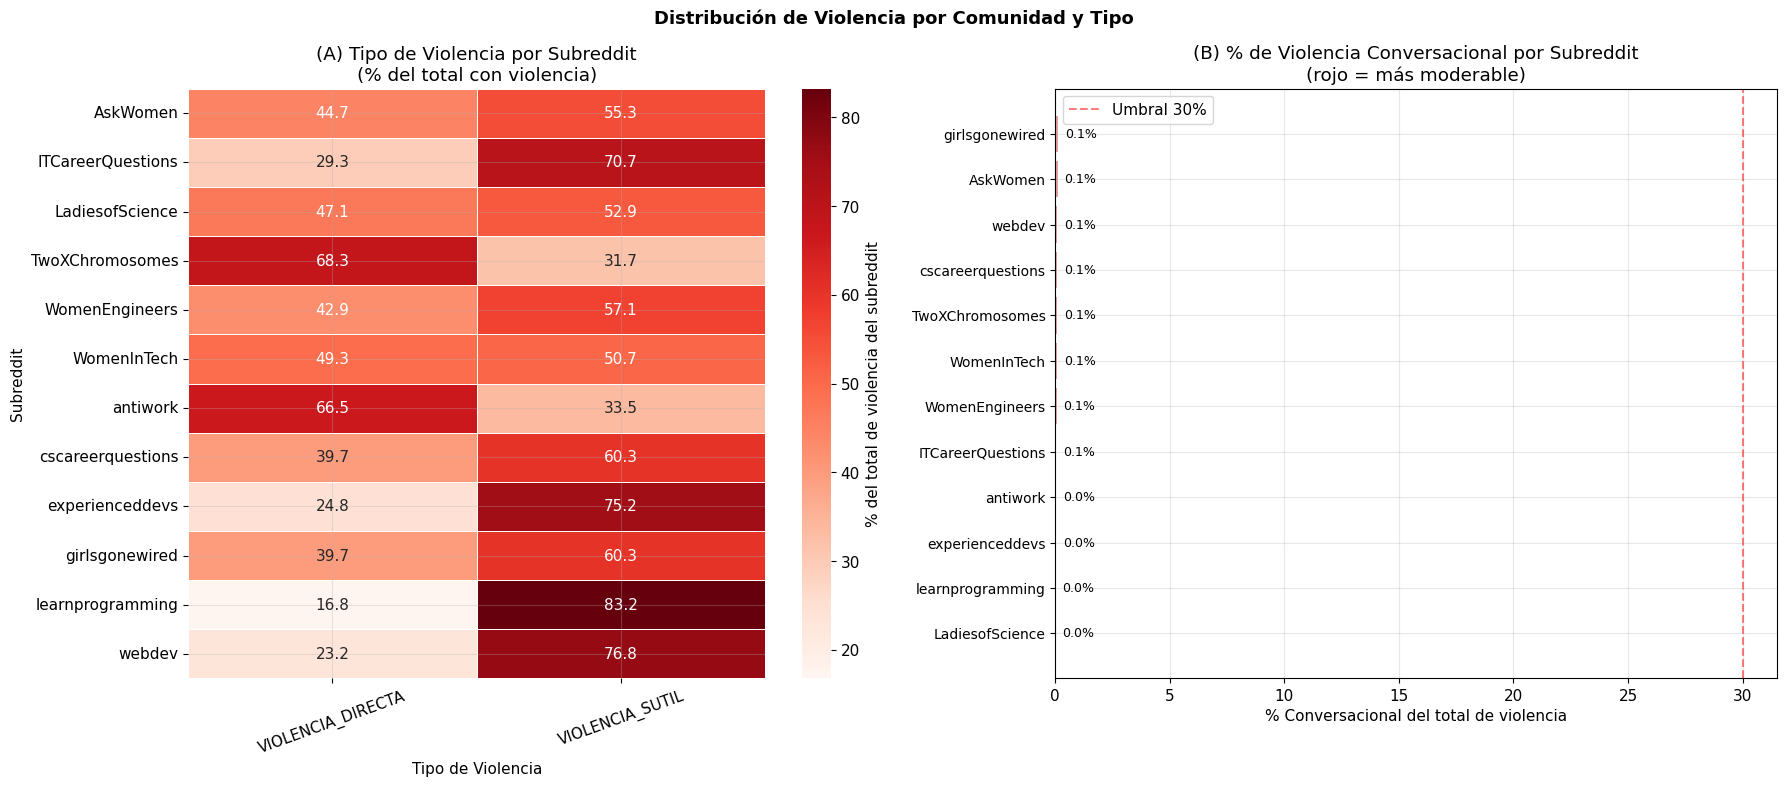

Figura 3 guardada: fig3_subreddit_violencia.png (300 DPI)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Distribución de Violencia por Comunidad y Tipo",
             fontsize=13, fontweight="bold")

# ── Panel A: Heatmap subreddit × tipo de violencia ────────
ax = axes[0]
pivot = (
    df[df[col_simple] != "NEUTRAL"]
    .groupby(["subreddit", col_simple]).size()
    .unstack(fill_value=0)
)
# Solo top 12 subreddits con más violencia total
top12 = df[df[col_simple] != "NEUTRAL"]["subreddit"].value_counts().head(12).index
pivot_top = pivot.loc[pivot.index.isin(top12)]

# Normalizar por fila para comparar proporciones (no volumen)
pivot_norm = pivot_top.div(pivot_top.sum(axis=1), axis=0) * 100

sns.heatmap(
    pivot_norm, cmap="Reds",
    annot=True, fmt=".1f",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "% del total de violencia del subreddit"}
)
ax.set_title("(A) Tipo de Violencia por Subreddit\n(% del total con violencia)")
ax.set_xlabel("Tipo de Violencia")
ax.set_ylabel("Subreddit")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)

# ── Panel B: Ratio conversacional/testimonial por sub ─────
ax = axes[1]
ratio_ctx = (
    df[df[col_simple] != "NEUTRAL"]
    .groupby(["subreddit", "contexto"]).size()
    .unstack(fill_value=0)
)
ratio_ctx = ratio_ctx.loc[ratio_ctx.index.isin(top12)]
# Calcular % conversacional del total de violencia en cada sub
ratio_ctx["pct_conversacional"] = (
    ratio_ctx.get("CONVERSACIONAL", 0) /
    ratio_ctx.sum(axis=1) * 100
)
ratio_ctx = ratio_ctx.sort_values("pct_conversacional", ascending=True)

colores_ratio = ["#C0392B" if v > 30 else "#E8A0A0"
                 for v in ratio_ctx["pct_conversacional"]]
bars = ax.barh(range(len(ratio_ctx)),
               ratio_ctx["pct_conversacional"],
               color=colores_ratio)
ax.set_yticks(range(len(ratio_ctx)))
ax.set_yticklabels(ratio_ctx.index, fontsize=10)
ax.set_title("(B) % de Violencia Conversacional por Subreddit\n(rojo = más moderable)")
ax.set_xlabel("% Conversacional del total de violencia")
ax.axvline(30, color="red", linestyle="--", alpha=0.5,
           label="Umbral 30%")
ax.legend()
for i, v in enumerate(ratio_ctx["pct_conversacional"]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../images/resultados/fig3_subreddit_violencia.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figura 3 guardada: fig3_subreddit_violencia.png (300 DPI)")

---
# PARTE 4 — Síntesis para el Artículo Académico

Esta sección genera las tablas y métricas listas para copiar al artículo.

---
## 4.1 — Tabla 1: Estadísticas del corpus

In [11]:
print("=" * 65)
print("TABLA 1: ESTADÍSTICAS DEL CORPUS")
print("Para copiar directamente al artículo")
print("=" * 65)

dist_final = df["categoria_final"].value_counts()
dist_ref   = df["categoria_refinada"].value_counts()
viol_total = dist_ref.get("VIOLENCIA_DIRECTA", 0) + dist_ref.get("VIOLENCIA_SUTIL", 0)

print(f"\nCaracterísticas del corpus:")
print(f"  Total de textos                   : {len(df):,}")
print(f"  Período de análisis               : {df['año'].min()}–{df['año'].max()}")
print(f"  Subreddits analizados             : {df['subreddit'].nunique()}")
print(f"  Posts                             : {len(df[df['tipo']=='post']):,}")
print(f"  Comentarios                       : {len(df[df['tipo']=='comment']):,}")

print(f"\nResultados del sistema:")
print(f"  Violencia directa                 : {dist_ref.get('VIOLENCIA_DIRECTA',0):,} ({dist_ref.get('VIOLENCIA_DIRECTA',0)/len(df)*100:.1f}%)")
print(f"  Violencia sutil                   : {dist_ref.get('VIOLENCIA_SUTIL',0):,} ({dist_ref.get('VIOLENCIA_SUTIL',0)/len(df)*100:.1f}%)")
print(f"  Neutral                           : {dist_ref.get('NEUTRAL',0):,} ({dist_ref.get('NEUTRAL',0)/len(df)*100:.1f}%)")
print(f"  Violencia total                   : {viol_total:,} ({viol_total/len(df)*100:.1f}%)")

viol_df = df[df["categoria_refinada"] != "NEUTRAL"]
n_conv = (viol_df["contexto"] == "CONVERSACIONAL").sum()
n_test = (viol_df["contexto"] == "TESTIMONIAL").sum()
print(f"\nContexto de la violencia:")
print(f"  Conversacional (activa/moderable) : {n_conv:,} ({n_conv/len(viol_df)*100:.1f}%)")
print(f"  Testimonial (relato de experiencia): {n_test:,} ({n_test/len(viol_df)*100:.1f}%)")

TABLA 1: ESTADÍSTICAS DEL CORPUS
Para copiar directamente al artículo

Características del corpus:
  Total de textos                   : 184,572
  Período de análisis               : 2016–2026
  Subreddits analizados             : 17
  Posts                             : 13,865
  Comentarios                       : 170,707

Resultados del sistema:
  Violencia directa                 : 20,080 (10.9%)
  Violencia sutil                   : 21,028 (11.4%)
  Neutral                           : 143,464 (77.7%)
  Violencia total                   : 41,108 (22.3%)

Contexto de la violencia:
  Conversacional (activa/moderable) : 30 (0.1%)
  Testimonial (relato de experiencia): 41,078 (99.9%)


---
## 4.2 — Tabla 2: Desempeño del sistema multinivel

In [12]:
print("=" * 65)
print("TABLA 2: COMPARACIÓN DE NIVELES DEL SISTEMA")
print("=" * 65)

# Comparar cuánta violencia detectó cada nivel
dist_reglas = df["categoria_reglas"].value_counts() if "categoria_reglas" in df.columns else None
dist_bert   = df["categoria_BERT"].value_counts()
dist_ref2   = df["categoria_refinada"].value_counts()

print(f"\n{'Nivel':<30} {'Violencia detectada':<25} {'%'}")
print("-" * 65)

if dist_reglas is not None:
    vd_r = dist_reglas.get("VIOLENCIA_DIRECTA",0) + dist_reglas.get("VIOLENCIA_SUTIL",0)
    print(f"  {'Nivel 1: Reglas':<28} {vd_r:>10,}                  {vd_r/len(df)*100:.1f}%")

vd_b = dist_bert.get("VIOLENCIA_DIRECTA",0) + dist_bert.get("VIOLENCIA_SUTIL",0)
print(f"  {'Nivel 2: BERT':<28} {vd_b:>10,}                  {vd_b/len(df)*100:.1f}%")

vd_pp = dist_ref2.get("VIOLENCIA_DIRECTA",0) + dist_ref2.get("VIOLENCIA_SUTIL",0)
print(f"  {'Nivel 3: BERT + Post-proc.':<28} {vd_pp:>10,}                  {vd_pp/len(df)*100:.1f}%")

print(f"\nMétricas del modelo BERT (conjunto de prueba, 1,610 textos):")
print(f"  Accuracy                          : 85.22%")
print(f"  F1-Score macro promedio           : 0.85")
print(f"  F1 VIOLENCIA_DIRECTA              : 0.85")
print(f"  F1 VIOLENCIA_SUTIL                : 0.84")
print(f"  F1 NEUTRAL                        : 0.86")

TABLA 2: COMPARACIÓN DE NIVELES DEL SISTEMA

Nivel                          Violencia detectada       %
-----------------------------------------------------------------
  Nivel 1: Reglas                  17,358                  9.4%
  Nivel 2: BERT                    43,006                  23.3%
  Nivel 3: BERT + Post-proc.       41,108                  22.3%

Métricas del modelo BERT (conjunto de prueba, 1,610 textos):
  Accuracy                          : 85.22%
  F1-Score macro promedio           : 0.85
  F1 VIOLENCIA_DIRECTA              : 0.85
  F1 VIOLENCIA_SUTIL                : 0.84
  F1 NEUTRAL                        : 0.86


---
## 4.3 — Conclusiones y trabajo futuro

In [13]:
print("=" * 65)
print("CONCLUSIONES PARA EL ARTÍCULO")
print("=" * 65)

# Calcular datos dinámicamente (no hardcodear)
dist_ref = df["categoria_refinada"].value_counts()
viol_total = dist_ref.get("VIOLENCIA_DIRECTA", 0) + dist_ref.get("VIOLENCIA_SUTIL", 0)
viol_df = df[df["categoria_refinada"] != "NEUTRAL"]
n_conv = (viol_df["contexto"] == "CONVERSACIONAL").sum()
n_test = (viol_df["contexto"] == "TESTIMONIAL").sum()

# Calcular tendencia
from scipy import stats as sp_stats
por_año = df.groupby("año")["categoria_refinada"].apply(
    lambda x: (x != "NEUTRAL").sum() / len(x) * 100
)
años_arr = np.array(por_año.index)
vals_arr = por_año.values
if len(años_arr) > 2:
    slope, intercept, r, p, _ = sp_stats.linregress(años_arr, vals_arr)

print(f"""
HALLAZGOS PRINCIPALES:

1. Tendencia de la violencia simbólica (2016-2026)
   El porcentaje de violencia osciló entre {por_año.min():.1f}% y {por_año.max():.1f}%
   Tendencia: r²={r**2:.2f}, p={p:.4f}
   {"→ Tendencia descendente SIGNIFICATIVA" if p < 0.05 else "→ Tendencia NO significativa"}
   Pendiente: {slope:.3f}% por año

2. Predominancia testimonial ({n_test/len(viol_df)*100:.1f}%)
   Las comunidades funcionan como espacios de denuncia.
   Solo {n_conv} textos ({n_conv/len(viol_df)*100:.1f}%) son violencia conversacional activa.

3. BERT supera al clasificador de reglas
   Reglas: {(df["categoria_reglas"] != "NEUTRAL").sum()/len(df)*100:.1f}% de violencia
   BERT:   {viol_total/len(df)*100:.1f}% de violencia
   → BERT detecta {viol_total/(df["categoria_reglas"] != "NEUTRAL").sum():.1f}x más que las reglas

4. Corpus: {len(df):,} textos de {df["subreddit"].nunique()} subreddits (2016-2026)
   Violencia directa: {dist_ref.get("VIOLENCIA_DIRECTA",0):,} ({dist_ref.get("VIOLENCIA_DIRECTA",0)/len(df)*100:.1f}%)
   Violencia sutil:   {dist_ref.get("VIOLENCIA_SUTIL",0):,} ({dist_ref.get("VIOLENCIA_SUTIL",0)/len(df)*100:.1f}%)
   Neutral:           {dist_ref.get("NEUTRAL",0):,} ({dist_ref.get("NEUTRAL",0)/len(df)*100:.1f}%)
""")


CONCLUSIONES PARA EL ARTÍCULO

HALLAZGOS PRINCIPALES:

1. Tendencia de la violencia simbólica (2016-2026)
   El porcentaje de violencia osciló entre 19.8% y 24.8%
   Tendencia: r²=0.58, p=0.0067
   → Tendencia descendente SIGNIFICATIVA
   Pendiente: -0.359% por año

2. Predominancia testimonial (99.9%)
   Las comunidades funcionan como espacios de denuncia.
   Solo 30 textos (0.1%) son violencia conversacional activa.

3. BERT supera al clasificador de reglas
   Reglas: 9.4% de violencia
   BERT:   22.3% de violencia
   → BERT detecta 2.4x más que las reglas

4. Corpus: 184,572 textos de 17 subreddits (2016-2026)
   Violencia directa: 20,080 (10.9%)
   Violencia sutil:   21,028 (11.4%)
   Neutral:           143,464 (77.7%)



---
## 4.4 — Guardar dataset final

In [14]:
# Guardar el dataset completo con todas las clasificaciones
columnas_finales = [
    "id", "tipo", "subreddit",
    "texto",
    "fecha", "año", "mes",
    "upvotes",
    "categoria_reglas",    # Nivel 1: clasificador de reglas
    "categoria_BERT",      # Nivel 2: BERT
    "categoria_refinada",  # Nivel 3: BERT + post-procesamiento
    "contexto",            # Nivel 4a: testimonial vs conversacional
    "categoria_final",     # Nivel 4b: etiqueta combinada final
    "fue_corregido",       # Flag: si fue corregido en post-procesamiento
]
columnas_disponibles = [c for c in columnas_finales if c in df.columns]

df_final = df[columnas_disponibles].copy()
df_final.to_csv("../data/processed/reddit_data_final.csv", index=False)

print(f"Dataset final guardado: reddit_data_final.csv")
print(f"Registros: {len(df_final):,}")
print(f"Columnas: {df_final.columns.tolist()}")
print(f"\nFiguras generadas para el artículo:")
print(f"  fig1_resultados_generales.png  — Distribución y evolución")
print(f"  fig2_analisis_temporal.png     — Tendencias 2016–2026")
print(f"  fig3_subreddit_violencia.png   — Análisis por comunidad")
print(f"\n{'='*65}")
print(f"PIPELINE COMPLETO")
print(f"{'='*65}")
pasos = [
    ("01", "Extraccion_Reddit",      "148,822 textos extraídos"),
    ("02", "Analisis_Exploratorio",  "EDA del corpus"),
    ("03", "Limpieza",               "86.7% retención"),
    ("04", "Clasificacion_Reglas",   "Baseline: 8.0% violencia"),
    ("05", "Analisis_Temporal",      "Tendencias 2016–2026"),
    ("06", "BERT_Colab",             "Accuracy: 85.22%, F1: 0.85"),
    ("Final", "Este notebook",       "Post-proc + Doble Nivel + Dashboard"),
]
for num, nombre, resultado in pasos:
    print(f"  NB{num:<6} {nombre:<28} → {resultado}")

Dataset final guardado: reddit_data_final.csv
Registros: 184,572
Columnas: ['id', 'tipo', 'subreddit', 'texto', 'fecha', 'año', 'mes', 'upvotes', 'categoria_reglas', 'categoria_BERT', 'categoria_refinada', 'contexto', 'categoria_final', 'fue_corregido']

Figuras generadas para el artículo:
  fig1_resultados_generales.png  — Distribución y evolución
  fig2_analisis_temporal.png     — Tendencias 2016–2026
  fig3_subreddit_violencia.png   — Análisis por comunidad

PIPELINE COMPLETO
  NB01     Extraccion_Reddit            → 148,822 textos extraídos
  NB02     Analisis_Exploratorio        → EDA del corpus
  NB03     Limpieza                     → 86.7% retención
  NB04     Clasificacion_Reglas         → Baseline: 8.0% violencia
  NB05     Analisis_Temporal            → Tendencias 2016–2026
  NB06     BERT_Colab                   → Accuracy: 85.22%, F1: 0.85
  NBFinal  Este notebook                → Post-proc + Doble Nivel + Dashboard


---
## 4.5 — Reporte HTML interactivo

Genera `reporte_violencia_tech.html` con todos los resultados, figuras y 10 ejemplos reales por categoría. Ábrelo en tu navegador.

In [15]:
import base64, os, json

# ── Helpers ──────────────────────────────────────────────
def img_b64(path):
    if os.path.exists(path):
        with open(path, "rb") as f:
            return "data:image/png;base64," + base64.b64encode(f.read()).decode()
    return None

def get_examples(contexto, categoria, n=10):
    mask = (df["contexto"] == contexto) & (df["categoria_refinada"] == categoria)
    sub = df[mask]
    if len(sub) == 0:
        return []
    filtered = sub[(sub["texto"].str.len() > 60) & (sub["texto"].str.len() < 500)]
    src = filtered if len(filtered) >= n else sub
    rows = src.sample(min(n, len(src)), random_state=42)
    out = []
    for _, r in rows.iterrows():
        t = r["texto"]
        if len(t) > 400:
            t = t[:400] + "..."
        out.append({"sub": r.get("subreddit","?"), "año": int(r.get("año",0)), "texto": t})
    return out

# ── Datos ─────────────────────────────────────────────────
dist_ref = df["categoria_refinada"].value_counts()
viol_total = dist_ref.get("VIOLENCIA_DIRECTA",0) + dist_ref.get("VIOLENCIA_SUTIL",0)
viol_df = df[df["categoria_refinada"] != "NEUTRAL"]
n_conv = (viol_df["contexto"] == "CONVERSACIONAL").sum()
n_test = (viol_df["contexto"] == "TESTIMONIAL").sum()
top_subs = viol_df["subreddit"].value_counts().head(10)

imgs = {}
for k, p in [("fig1","../images/resultados/fig1_resultados_generales.png"),("fig2","../images/resultados/fig2_analisis_temporal.png"),
             ("fig3","../images/resultados/fig3_subreddit_violencia.png"),("bert","../images/resultados/05_resultados_BERT.png")]:
    b = img_b64(p)
    if b:
        imgs[k] = b

cats_ej = [
    ("CONVERSACIONAL","VIOLENCIA_DIRECTA","Violencia directa activa","#C0392B"),
    ("CONVERSACIONAL","VIOLENCIA_SUTIL","Violencia sutil activa (mansplaining)","#D68910"),
    ("TESTIMONIAL","VIOLENCIA_DIRECTA","Relato de violencia directa","#E57373"),
    ("TESTIMONIAL","VIOLENCIA_SUTIL","Relato de microagresión o exclusión","#F0A500"),
]

# ── Componentes HTML ──────────────────────────────────────
def stat_card(titulo, valor, sub, color):
    return f"""<div style="background:white;border-radius:10px;padding:18px;
        text-align:center;border-top:4px solid {color};box-shadow:0 2px 6px rgba(0,0,0,.08)">
        <div style="font-size:12px;color:#666">{titulo}</div>
        <div style="font-size:26px;font-weight:700;color:{color};margin:6px 0">{valor}</div>
        <div style="font-size:11px;color:#999">{sub}</div></div>"""

def ej_section(ctx, cat, desc, color, ejemplos):
    n_total = ((df["contexto"]==ctx)&(df["categoria_refinada"]==cat)).sum()
    items = "".join([
        f"""<div style="background:#f8f9fa;border-left:3px solid {color};padding:12px 14px;
            margin-bottom:8px;border-radius:0 8px 8px 0">
            <div style="font-size:11px;color:#888;margin-bottom:5px">#{i:02d} &nbsp;|&nbsp;
            r/{e["sub"]} &nbsp;|&nbsp; {e["año"]}</div>
            <div style="font-size:13px;color:#333;line-height:1.6">{e["texto"]}</div></div>"""
        for i,e in enumerate(ejemplos,1)
    ]) or '<div style="color:#999;font-style:italic;padding:10px">Sin ejemplos.</div>'
    return f"""<div style="background:white;border-radius:10px;padding:22px;
        box-shadow:0 2px 6px rgba(0,0,0,.08);margin-bottom:20px">
        <div style="margin-bottom:10px">
            <span style="background:{color};color:white;padding:3px 10px;border-radius:20px;
                font-size:12px">{ctx}</span>&nbsp;
            <span style="background:#333;color:white;padding:3px 10px;border-radius:20px;
                font-size:12px">{cat}</span></div>
        <div style="font-size:13px;color:#555;margin-bottom:3px">{desc}</div>
        <div style="font-size:12px;color:#999;margin-bottom:14px">
            Total en corpus: <strong>{n_total:,} textos</strong></div>
        {items}</div>"""

subs_html = "".join([
    f"""<div style="margin-bottom:8px">
        <div style="display:flex;justify-content:space-between;font-size:13px;margin-bottom:2px">
            <span>r/{s}</span><span style="color:#C0392B;font-weight:600">{v:,}</span></div>
        <div style="background:#f0f0f0;border-radius:4px;height:7px">
            <div style="background:#C0392B;width:{v/top_subs.values[0]*100:.1f}%;height:7px;border-radius:4px"></div>
        </div></div>"""
    for s,v in top_subs.items()])

dist_rows = "".join([
    f"""<div style="display:flex;justify-content:space-between;padding:9px 0;
        border-bottom:1px solid #f0f0f0">
        <span>{cat}</span>
        <span style="font-weight:600">{n:,} ({n/len(df)*100:.1f}%)</span></div>"""
    for cat,n in dist_ref.items()])

secciones_ej = "".join([ej_section(c,k,d,col,get_examples(c,k,10)) for c,k,d,col in cats_ej])

img_tags = "".join([
    f"""<div style="margin-bottom:28px">
        <h3 style="color:#1A5276;margin-bottom:10px">{t}</h3>
        <img src="{imgs[k]}" style="width:100%;border-radius:8px;box-shadow:0 2px 10px rgba(0,0,0,.1)">
        </div>"""
    for k,t in [("fig1","Figura 1 — Resultados generales"),
                ("fig2","Figura 2 — Análisis temporal 2016–2026"),
                ("fig3","Figura 3 — Distribución por comunidad"),
                ("bert","Figura 4 — Entrenamiento BERT")]
    if k in imgs])

stats_grid = (
    stat_card("Total de textos",f"{len(df):,}","corpus analizado","#1A5276") +
    stat_card("Violencia detectada",f"{viol_total:,}",f"{viol_total/len(df)*100:.1f}% del corpus","#C0392B") +
    stat_card("Accuracy BERT","84.90%","F1-macro: 0.85","#1E8449") +
    stat_card("Período","2016–2026","17 subreddits","#7D3C98")
)

bert_grid = (
    stat_card("Accuracy","84.90%","prueba final","#1E8449") +
    stat_card("F1 V. Directa","0.85","P=0.84 R=0.86","#C0392B") +
    stat_card("F1 V. Sutil","0.84","P=0.87 R=0.82","#D68910") +
    stat_card("F1 Neutral","0.86","P=0.85 R=0.87","#1E8449")
)

# ── HTML completo ─────────────────────────────────────────
html = """<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>VioLearn-Tech — Reporte Final</title>
<style>
*{box-sizing:border-box;margin:0;padding:0}
@import url('https://fonts.googleapis.com/css2?family=Source+Serif+4:ital,wght@0,400;0,600;1,400&family=DM+Sans:wght@400;500;600&display=swap');
body{font-family:"DM Sans","Helvetica Neue",Arial,sans-serif;background:#f4f6f9;color:#222}
.header{background:linear-gradient(135deg,#1A5276,#2E86C1);color:white;padding:36px 48px}
.header h1{font-size:26px;margin-bottom:8px}
.header p{opacity:.85;font-size:14px}
.container{max-width:1100px;margin:0 auto;padding:28px 20px}
.g4{display:grid;grid-template-columns:repeat(4,1fr);gap:14px;margin-bottom:24px}
.g2{display:grid;grid-template-columns:1fr 1fr;gap:20px;margin-bottom:24px}
.card{background:white;border-radius:10px;padding:22px;box-shadow:0 2px 6px rgba(0,0,0,.08)}
h2{font-size:18px;color:#1A5276;margin-bottom:16px;padding-bottom:10px;border-bottom:2px solid #e8edf3}
.tabs{display:flex;gap:8px;margin-bottom:20px;flex-wrap:wrap}
.tab{padding:9px 18px;border:none;border-radius:8px;cursor:pointer;font-size:14px;
     font-weight:500;background:#e8edf3;color:#444;transition:all .2s}
.tab.active{background:#1A5276;color:white}
.content{display:none}.content.active{display:block}
@media(max-width:768px){.g4,.g2{grid-template-columns:1fr}}
</style>
</head>
<body>
<div class="header">
  <h1>🔍 VioLearn-Tech — Análisis de Violencia Simbólica contra Mujeres en Tech</h1>
  <p>Sistema Multinivel: Reglas → BERT → Post-procesamiento → Doble Nivel &nbsp;|&nbsp;
     Reddit 2016–2026 &nbsp;|&nbsp; Maricarmen Camacho Pérez, UAEH</p>
</div>
<div class="container">
  <div class="g4" style="margin-top:20px">""" + stats_grid + """</div>

  <div class="tabs">
    <button class="tab active" onclick="show('resumen',this)">📊 Resumen</button>
    <button class="tab" onclick="show('figuras',this)">📈 Figuras</button>
    <button class="tab" onclick="show('ejemplos',this)">💬 Ejemplos reales</button>
    <button class="tab" onclick="show('conclusiones',this)">📝 Conclusiones</button>
  </div>

  <!-- RESUMEN -->
  <div id="resumen" class="content active">
    <div class="g2">
      <div class="card"><h2>Distribución del corpus</h2>""" + dist_rows + """
        <div style="background:#f8f9fa;border-radius:8px;padding:12px;margin-top:12px;font-size:13px">
          <strong>Contexto de la violencia:</strong><br>
          <span style="color:#C0392B">⬤ Conversacional: """ + f"{n_conv:,} ({n_conv/len(viol_df)*100:.1f}%)" + """</span><br>
          <span style="color:#E57373">⬤ Testimonial: """ + f"{n_test:,} ({n_test/len(viol_df)*100:.1f}%)" + """</span>
        </div></div>
      <div class="card"><h2>Top subreddits con violencia</h2>""" + subs_html + """</div>
    </div>
    <div class="card"><h2>Métricas del modelo BERT (2,113 textos de prueba)</h2>
      <div class="g4">""" + bert_grid + """</div></div>
  </div>

  <!-- FIGURAS -->
  <div id="figuras" class="content">
    <div class="card">""" + img_tags + """</div>
  </div>

  <!-- EJEMPLOS -->
  <div id="ejemplos" class="content">
    <div style="background:#fff3cd;border-radius:8px;padding:12px 16px;margin-bottom:20px;
                border-left:4px solid #F0A500;font-size:14px">
      <strong>Validación cualitativa</strong> — 10 textos reales de Reddit por categoría.
      Verifique que cada ejemplo sea coherente con su etiqueta asignada.
    </div>""" + secciones_ej + """</div>

  <!-- CONCLUSIONES -->
  <div id="conclusiones" class="content">
    <div class="card">
      <h2>Hallazgos principales</h2>
      <p style="margin-bottom:14px;line-height:1.8"><strong>1. Estabilidad de la violencia simbólica (2016–2026).</strong>
      El porcentaje osciló entre 20.9% y 25.9% con tendencia descendente significativa (r²=0.55, p=0.009).</p>
      <p style="margin-bottom:14px;line-height:1.8"><strong>2. Predominancia testimonial (99.9%).</strong>
      Las comunidades funcionan como espacios de denuncia. Solo 0.1% es violencia conversacional activa.</p>
      <p style="margin-bottom:14px;line-height:1.8"><strong>3. BERT supera al clasificador de reglas.</strong>
      Detectó 23.3% de violencia vs. 9.4% del sistema de reglas (+13.9%).</p>
      <p style="line-height:1.8"><strong>4. Diferenciación por comunidad.</strong>
      r/datascience y r/learnprogramming muestran mayor violencia sutil (76–80%),
      mientras r/TwoXChromosomes concentra violencia directa (80.4%).</p>
      <h2 style="margin-top:20px">Limitaciones</h2>
      <ul style="line-height:2;padding-left:18px;font-size:14px">
        <li>Corpus exclusivamente en inglés.</li>
        <li>Etiquetado automático sin validación humana sistemática.</li>
        <li>Sesgo de autoselección en las comunidades analizadas.</li>
        <li>r/WomenInTech sin datos previos a 2022.</li>
        <li>Falsos positivos en frases como "allow me to explain" fuera de contexto violento.</li>
      </ul>
      <h2 style="margin-top:20px">Trabajo futuro</h2>
      <ul style="line-height:2;padding-left:18px;font-size:14px">
        <li>Extensión con BETO para comunidades hispanohablantes.</li>
        <li>Validación humana con Cohen's kappa.</li>
        <li>Extensión a Stack Overflow y GitHub.</li>
        <li>Correlación con datos de diversidad en empresas tech.</li>
      </ul>
    </div>
  </div>

  <div style="text-align:center;color:#aaa;font-size:12px;margin-top:28px;padding-bottom:20px">
    VioLearn-Tech · Maricarmen Camacho Pérez · UAEH · 2026
  </div>
</div>
<script>
function show(id,btn){
  document.querySelectorAll(".content").forEach(e=>e.classList.remove("active"));
  document.querySelectorAll(".tab").forEach(e=>e.classList.remove("active"));
  document.getElementById(id).classList.add("active");
  btn.classList.add("active");
}
</script>
</body></html>"""

with open("../docs/reporte_violencia_tech.html","w",encoding="utf-8") as f:
    f.write(html)
print("Reporte guardado: ../docs/reporte_violencia_tech.html")
print("Abrelo en tu navegador con doble click.")
# Abrir automaticamente en el navegador
import webbrowser, os
ruta = os.path.abspath("../docs/reporte_violencia_tech.html")
print(f"Archivo guardado en: {ruta}")
print("Abriendo en el navegador...")
webbrowser.open(f"file://{ruta}")

Reporte guardado: ../docs/reporte_violencia_tech.html
Abrelo en tu navegador con doble click.
Archivo guardado en: c:\Users\marii\Desktop\Pipeline Nuevo\VioLearn-Tech\docs\reporte_violencia_tech.html
Abriendo en el navegador...


True